# Data Mining Assignment — Exploratory Data Analysis Appendix

**Dataset:** Default of Credit Card Clients (Taiwan, 2005) — UCI ML Repository id=350
<https://github.com/busta432/DataMining-Credit-Card-Defaults.git>

This appendix follows the **CRISP-DM** ordering (Chapman et al., 2000): *Data Understanding*
(§1, profiling the raw data as delivered) precedes *Data Preparation* (§2, cleaning), so that
every cleaning rule is argued from evidence gathered before the data was altered.

| Section | Content |
|---|---|
| §0 | Data loading and programmatic column naming |
| §1 | Raw profiling and data-quality audit — **observe only, no mutation** |
| §2 | Cleaning — each rule justified by a §1 finding |
| §3 | Univariate analysis — distributions, five-number summaries, outliers |
| §4 | Bivariate analysis — the demographic bias baseline |

Design decisions and their justifications are recorded in `Decisions.md`.
Phase 2 (PCA, mutual-information leakage) and Phase 3 (Markov delinquency dynamics)
are tracked in `PROJECT_TRACKER.md`.

## §0 Setup

Plot styling follows a validated categorical palette: hues are assigned in a fixed order
(never cycled), sequential magnitude uses a single hue light→dark, and chart chrome
(grid, axes) is recessive relative to the data marks.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

from ucimlrepo import fetch_ucirepo
from scipy import stats

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

# --- Validated palette -------------------------------------------------------
# Categorical slots are assigned in fixed order and never cycled past slot 8.
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"   # primary text
INK_2     = "#52514e"   # secondary text
MUTED     = "#898781"   # axis / tick labels
GRID      = "#e1e0d9"   # hairline gridline
AXIS      = "#c3c2b7"   # baseline

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
       "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

# Sequential ramp (single hue, light -> dark) for magnitude encodings.
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
       "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
SEQ_CMAP = mpl.colors.LinearSegmentedColormap.from_list("seq_blue", SEQ)

CRITICAL = "#d03b3b"   # status colour, reserved for "this is the problem"

mpl.rcParams.update({
    "figure.facecolor":  SURFACE,
    "axes.facecolor":    SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor":    AXIS,
    "axes.linewidth":    0.8,
    "axes.labelcolor":   INK_2,
    "axes.titlecolor":   INK,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "axes.titlelocation": "left",
    "axes.titlepad":     10,
    "axes.labelsize":    9.5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        GRID,
    "grid.linewidth":    0.8,
    "grid.linestyle":    "-",       # solid hairlines, never dashed
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "xtick.labelsize":   8.5,
    "ytick.labelsize":   8.5,
    "text.color":        INK,
    "font.size":         9.5,
    "font.family":       "sans-serif",
    "legend.frameon":    False,
    "legend.fontsize":   9,
    "figure.dpi":        110,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
})


def save_fig(fig, name):
    """Write a figure to figures/<name>.png at 150 dpi for the proposal document."""
    path = FIGDIR / f"{name}.png"
    fig.savefig(path)
    print(f"saved -> {path}")


def thousands(x, _pos=None):
    return f"{x:,.0f}"


KFMT = FuncFormatter(thousands)


def rate_bars(ax, rates, los, his, counts, labels, title, *,
              colours=None, overall=None, xlabel=None, rotate=0, pct_fmt="{:.2f}%"):
    """Standard default-rate bar panel: Wilson CIs, counts in the tick labels.

    Counts go in the axis labels rather than inside the bars, so they can neither
    collide with a short bar nor sit at low contrast on a coloured fill. Value
    labels are placed above the CI whisker, never above the bar, so they cannot
    overlap the interval.
    """
    rates, los, his = np.asarray(rates), np.asarray(los), np.asarray(his)
    x = np.arange(len(rates))
    ax.bar(x, rates, color=(colours if colours is not None else CAT[0]),
           width=0.62, zorder=3)
    ax.errorbar(x, rates, yerr=[rates - los, his - rates], fmt="none",
                ecolor=INK_2, elinewidth=1.1, capsize=4, zorder=4)

    top = float(his.max())
    ax.set_ylim(0, top * 1.24)
    for xi, r, h in zip(x, rates, his):
        ax.text(xi, h + top * 0.045, pct_fmt.format(r), ha="center", va="bottom",
                fontsize=8.5, color=INK, zorder=5)

    if overall is not None:
        ax.axhline(overall, color=AXIS, lw=1.1, zorder=2,
                   label=f"overall {overall:.2f}%")

    ax.set_xticks(x, [f"{labels[i]}\nn={c:,}" for i, c in enumerate(counts)],
                  rotation=rotate)
    if rotate:
        for lb in ax.get_xticklabels():
            lb.set_ha("right")
    ax.set_ylabel("Default rate (%)")
    if xlabel:
        ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)


print("Setup complete.")

Setup complete.


## §0.1 Data loading and column naming

`ucimlrepo` returns this dataset with **placeholder column names `X1`–`X23`** and target `Y`,
not the documented feature names. The real names are carried in the `variables` metadata
frame, in its `description` field. The rename is therefore built **programmatically from that
metadata** rather than hardcoded, so it cannot silently drift if the upstream column order
ever changes.

Two structural properties of this dataset are recorded here because they are easy to get
wrong and affect every later section:

1. **The repayment/bill columns are reverse-chronological.** `PAY_0` and `BILL_AMT1` are
   September 2005 (the most recent month); `PAY_6` and `BILL_AMT6` are April 2005 (the
   oldest). Chronological order is therefore `PAY_6 → PAY_5 → PAY_4 → PAY_3 → PAY_2 → PAY_0`.
2. **There is no `PAY_1`.** The September column is named `PAY_0`, a known quirk of the
   original release.

In [2]:
raw_repo = fetch_ucirepo(id=350)

# Build the rename map from the metadata's `description` field (X1 -> LIMIT_BAL, ...).
name_map = {
    r["name"]: r["description"]
    for _, r in raw_repo.variables.iterrows()
    if isinstance(r.get("description"), str) and r["description"].strip()
}

raw = raw_repo.data.features.rename(columns=name_map).copy()
raw["DEFAULT"] = raw_repo.data.targets.iloc[:, 0].values

# Column groups used throughout the appendix.
DEMOGRAPHIC = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
PAY_COLS    = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
PAY_CHRONO  = ["PAY_6", "PAY_5", "PAY_4", "PAY_3", "PAY_2", "PAY_0"]   # April -> September
BILL_COLS   = [f"BILL_AMT{i}" for i in range(1, 7)]
PAYAMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]
CONTINUOUS  = ["LIMIT_BAL", "AGE"] + BILL_COLS + PAYAMT_COLS
MONTH_LABEL = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]                # chronological

assert list(raw.columns[:5]) == ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"], \
    "Programmatic rename failed - check variables metadata"
assert raw.shape == (30000, 24), f"Unexpected raw shape {raw.shape}"

print(f"Raw data: {raw.shape[0]:,} rows x {raw.shape[1] - 1} explanatory variables + target")
print(f"Columns: {list(raw.columns)}")

Raw data: 30,000 rows x 23 explanatory variables + target
Columns: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


## §1 Raw profiling and data-quality audit

**No values are modified in this section.** Its purpose is to establish, from the data as
delivered, exactly what is wrong with it — so that each cleaning rule applied in §2 can be
justified by evidence rather than by convention alone.

### §1.1 The target variable

In [3]:
n_rows = len(raw)
n_default = int(raw["DEFAULT"].sum())
default_rate = raw["DEFAULT"].mean()

print(f"Observations           : {n_rows:,}")
print(f"Defaulted next month   : {n_default:,}  ({default_rate:.2%})")
print(f"Did not default        : {n_rows - n_default:,}  ({1 - default_rate:.2%})")
print(f"Imbalance ratio        : {(n_rows - n_default) / n_default:.2f} : 1")

assert (n_rows, n_default) == (30000, 6636), "Target counts do not match the published dataset"

Observations           : 30,000
Defaulted next month   : 6,636  (22.12%)
Did not default        : 23,364  (77.88%)
Imbalance ratio        : 3.52 : 1


The target is **imbalanced at 22.12%** — roughly 3.5 non-defaulters per defaulter. This is
mild by the standards of the imbalanced-learning literature, but it is severe enough that
*accuracy is not a usable metric*: a classifier predicting "no default" for every client
scores 77.88% accuracy while identifying no defaulters at all. This motivates
precision–recall-based evaluation later (He & Garcia, 2009; Saito & Rehmsmeier, 2015).

### §1.2 Data-quality overview

Missingness is not this dataset's problem — there are no nulls anywhere. Its problems are
**semantic**: category codes that the official data dictionary does not define, exact
duplicate records, and values whose sign contradicts a naive reading of the variable.

In [4]:
# --- Quantify every data-quality issue on the RAW data -----------------------
edu_undoc  = raw["EDUCATION"].isin([0, 5, 6])
mar_undoc  = raw["MARRIAGE"].eq(0)
pay_undoc  = raw[PAY_COLS].isin([-2, 0]).any(axis=1)
neg_bill   = (raw[BILL_COLS] < 0).any(axis=1)
dup_mask   = raw.drop(columns="DEFAULT").duplicated(keep=False)

dq = pd.DataFrame([
    ("Missing values (any column)",              int(raw.isna().any(axis=1).sum())),
    ("MARRIAGE: undocumented code 0",            int(mar_undoc.sum())),
    ("Duplicate records (all rows in a group)",  int(dup_mask.sum())),
    ("EDUCATION: undocumented codes 0, 5, 6",    int(edu_undoc.sum())),
    ("Negative BILL_AMT (any month)",            int(neg_bill.sum())),
    ("PAY_n: undocumented codes -2 or 0 (any month)", int(pay_undoc.sum())),
], columns=["Issue", "Rows affected"])
dq["% of data"] = (dq["Rows affected"] / n_rows * 100).round(2)

assert int(raw.isna().sum().sum()) == 0, "Unexpected nulls"
display(dq.set_index("Issue"))

,Rows affected,% of data
Issue,,
Missing values (any column),0,0.00
MARRIAGE: undocumented code 0,54,0.18
Duplicate records (all rows in a group),108,0.36
"EDUCATION: undocumented codes 0, 5, 6",345,1.15
Negative BILL_AMT (any month),1930,6.43
PAY_n: undocumented codes -2 or 0 (any month),25939,86.46


saved -> figures/dq1_quality_overview.png


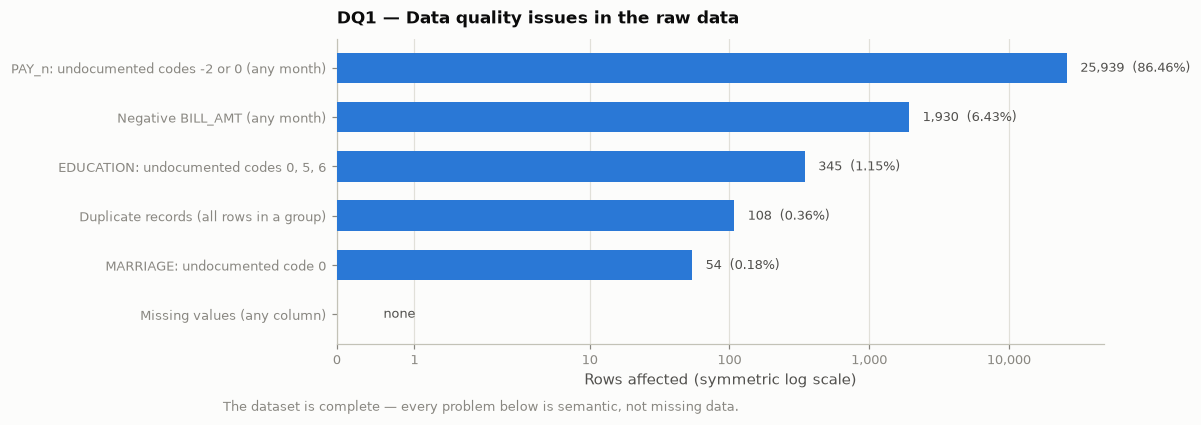

In [5]:
# --- DQ1: data-quality issues by rows affected -------------------------------
d = dq.sort_values("Rows affected")
fig, ax = plt.subplots(figsize=(9, 3.6))

bars = ax.barh(d["Issue"], d["Rows affected"], height=0.62, color=CAT[0], zorder=3)
ax.set_xscale("symlog")
ax.set_xlim(0, n_rows * 1.6)
ax.set_xlabel("Rows affected (symmetric log scale)")
ax.set_title("DQ1 — Data quality issues in the raw data")
ax.xaxis.set_major_formatter(KFMT)
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)

for bar, v, pct in zip(bars, d["Rows affected"], d["% of data"]):
    label = "none" if v == 0 else f"{v:,}  ({pct:.2f}%)"
    ax.text(bar.get_width() + (0.6 if v == 0 else v * 0.25), bar.get_y() + bar.get_height() / 2,
            label, va="center", ha="left", fontsize=8.5, color=INK_2)

fig.text(0.01, -0.06,
         "The dataset is complete — every problem below is semantic, not missing data.",
         fontsize=8.5, color=MUTED)
save_fig(fig, "dq1_quality_overview")
plt.show()

The single most consequential row is the last one: **more than 80% of clients carry an
undocumented `PAY_n` code in at least one month.** The data dictionary defines `PAY_n` as
`-1 = paid duly` and `1..9 = payment delay in months`, but the data also contains `-2` and
`0` — and `0` is the single most common value in every month. This is examined in §1.4.

### §1.3 Undocumented demographic category codes

saved -> figures/dq2_undocumented_categories.png


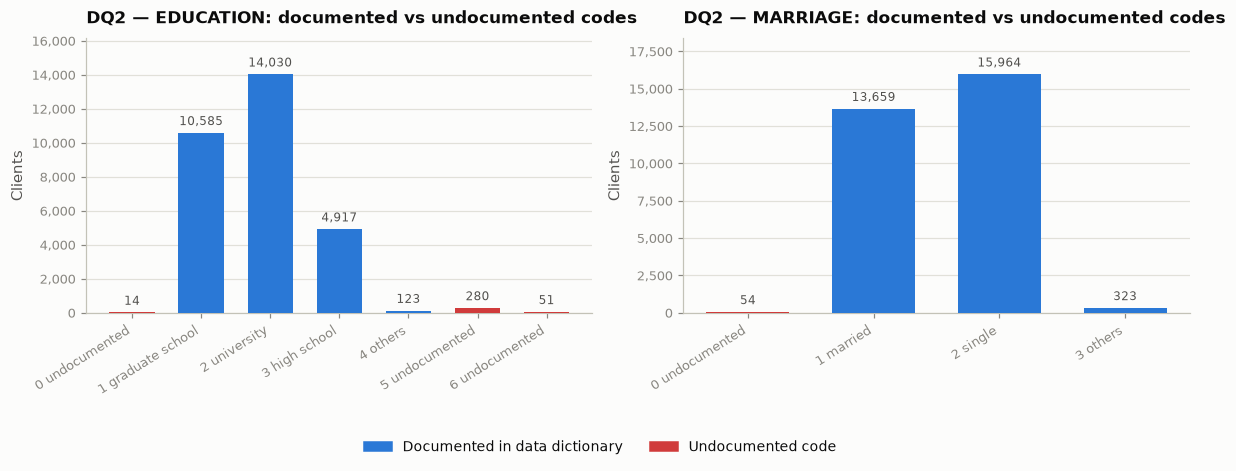

EDUCATION undocumented: 345 rows (1.15%)   codes [np.int64(0), np.int64(5), np.int64(6)]
MARRIAGE  undocumented: 54 rows (0.18%)   codes [np.int64(0)]


In [6]:
EDU_LABEL = {1: "1 graduate school", 2: "2 university", 3: "3 high school",
             4: "4 others", 0: "0 undocumented", 5: "5 undocumented", 6: "6 undocumented"}
MAR_LABEL = {1: "1 married", 2: "2 single", 3: "3 others", 0: "0 undocumented"}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for ax, col, labels, undoc in [
    (axes[0], "EDUCATION", EDU_LABEL, {0, 5, 6}),
    (axes[1], "MARRIAGE",  MAR_LABEL, {0}),
]:
    vc = raw[col].value_counts().sort_index()
    colours = [CRITICAL if k in undoc else CAT[0] for k in vc.index]
    bars = ax.bar([labels[k] for k in vc.index], vc.values, color=colours, width=0.66, zorder=3)
    ax.set_title(f"DQ2 — {col}: documented vs undocumented codes")
    ax.set_ylabel("Clients")
    ax.yaxis.set_major_formatter(KFMT)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=32)
    for lb in ax.get_xticklabels():
        lb.set_ha("right")
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + vc.max() * 0.02,
                f"{v:,}", ha="center", va="bottom", fontsize=8, color=INK_2)
    ax.set_ylim(0, vc.max() * 1.15)

handles = [mpl.patches.Patch(color=CAT[0], label="Documented in data dictionary"),
           mpl.patches.Patch(color=CRITICAL, label="Undocumented code")]
fig.legend(handles=handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.13))
fig.tight_layout()
save_fig(fig, "dq2_undocumented_categories")
plt.show()

print(f"EDUCATION undocumented: {int(edu_undoc.sum())} rows "
      f"({edu_undoc.mean() * 100:.2f}%)   codes {sorted(raw.loc[edu_undoc, 'EDUCATION'].unique())}")
print(f"MARRIAGE  undocumented: {int(mar_undoc.sum())} rows "
      f"({mar_undoc.mean() * 100:.2f}%)   codes {sorted(raw.loc[mar_undoc, 'MARRIAGE'].unique())}")

The official dictionary defines `EDUCATION` as `1 = graduate school, 2 = university,
3 = high school, 4 = others` and `MARRIAGE` as `1 = married, 2 = single, 3 = others`.
The data contains `EDUCATION ∈ {0, 5, 6}` (345 clients) and `MARRIAGE = 0` (54 clients).
These are undefined — there is no published statement of what they mean.

### §1.4 The `PAY_n` encoding problem

The repayment-status columns are the strongest predictors in this dataset, so their encoding
matters more than any other. The dictionary documents `-1 = paid duly` and `1..9 = months of
delay`, which accounts for neither `-2` nor `0`.

saved -> figures/dq3_pay_state_frequency.png


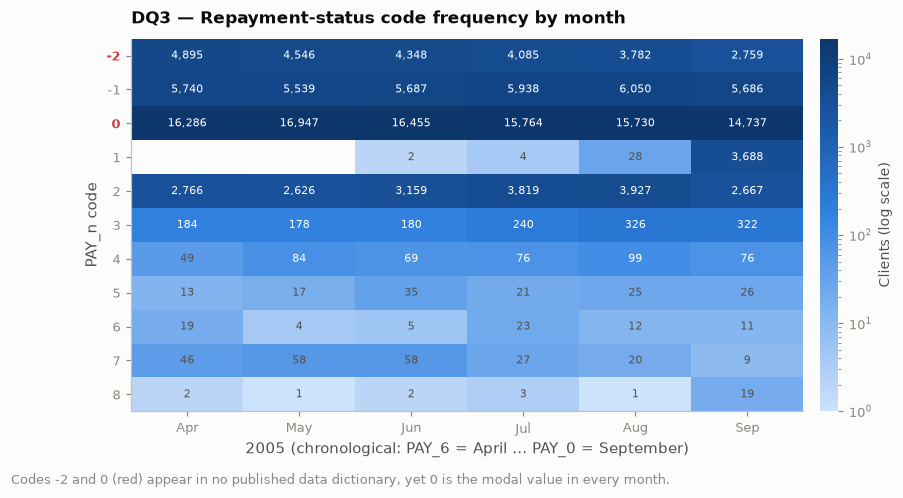

,-2,-1,0,1,2,3,4,5,6,7,8
Apr,4895,5740,16286,0,2766,184,49,13,19,46,2
May,4546,5539,16947,0,2626,178,84,17,4,58,1
Jun,4348,5687,16455,2,3159,180,69,35,5,58,2
Jul,4085,5938,15764,4,3819,240,76,21,23,27,3
Aug,3782,6050,15730,28,3927,326,99,25,12,20,1
Sep,2759,5686,14737,3688,2667,322,76,26,11,9,19


In [7]:
# --- DQ3: PAY_n state frequency across the six months ------------------------
states = sorted(set(np.concatenate([raw[c].unique() for c in PAY_COLS])))
mat = pd.DataFrame({m: raw[c].value_counts().reindex(states, fill_value=0)
                    for c, m in zip(PAY_CHRONO, MONTH_LABEL)})

fig, ax = plt.subplots(figsize=(9.5, 4.4))
im = ax.imshow(mat.values, aspect="auto", cmap=SEQ_CMAP,
               norm=mpl.colors.LogNorm(vmin=1, vmax=mat.values.max()))

ax.set_xticks(range(len(MONTH_LABEL)), MONTH_LABEL)
ax.set_yticks(range(len(states)), [str(s) for s in states])
ax.set_xlabel("2005 (chronological: PAY_6 = April … PAY_0 = September)")
ax.set_ylabel("PAY_n code")
ax.set_title("DQ3 — Repayment-status code frequency by month")
ax.grid(False)

for i, s in enumerate(states):
    for j in range(len(MONTH_LABEL)):
        v = mat.values[i, j]
        if v == 0:
            continue
        shade = im.cmap(im.norm(v))
        lum = 0.299 * shade[0] + 0.587 * shade[1] + 0.114 * shade[2]
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=7.5,
                color="#ffffff" if lum < 0.55 else INK_2)

# Mark the undocumented codes on the y-axis.
for i, s in enumerate(states):
    if s in (-2, 0):
        ax.get_yticklabels()[i].set_color(CRITICAL)
        ax.get_yticklabels()[i].set_fontweight("bold")

cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label("Clients (log scale)", color=INK_2, fontsize=9)
cb.outline.set_visible(False)

fig.text(0.01, -0.04,
         "Codes -2 and 0 (red) appear in no published data dictionary, yet 0 is the modal "
         "value in every month.", fontsize=8.5, color=MUTED)
save_fig(fig, "dq3_pay_state_frequency")
plt.show()

display(mat.T)

`0` is the modal repayment code in **every one of the six months**, accounting for roughly
half of all client-months, and `-2` is the third most common. Together the two undocumented
codes cover the overwhelming majority of the data — they cannot be treated as stray noise.

The heatmap also exposes a second, subtler artefact that is easy to miss in a summary table:
**code `1` is almost entirely absent before September.** It occurs 0, 0, 2, 4 and 28 times in
April through August, then 3,688 times in September. A genuine behavioural variable would not
jump by two orders of magnitude in its final month. The most plausible explanation is that
the September column (`PAY_0`) was derived or coded differently from the historical columns —
which is consistent with it also being the only column whose name breaks the `PAY_n` numbering
convention. This is recorded as a limitation: `PAY_0` is the single most predictive variable
in the dataset (§4.4), and it may not be measured on quite the same basis as its five
predecessors.

The interpretation adopted in this appendix, which is the consensus reading in the applied
literature on this dataset, is:

| code | meaning |
|---|---|
| `-2` | no consumption / no balance that month (account dormant) |
| `-1` | balance paid in full |
| `0`  | revolving credit — the minimum payment was made but a balance was carried |
| `1..9` | payment delayed by that many months |

Under this reading the three non-positive codes are *not* interchangeable: they describe
dormant, fully-paid, and revolving accounts respectively. §4 tests whether they behave
differently with respect to default, and finds that they do.

### §1.5 Duplicate records

In [8]:
feat_cols = [c for c in raw.columns if c != "DEFAULT"]
dups = raw[dup_mask]
groups = raw[dup_mask].groupby(feat_cols, sort=False)["DEFAULT"]
contradictory = int((groups.nunique() > 1).sum())
n_groups = groups.ngroups
excess = int(raw[feat_cols].duplicated().sum())

zero_bill_dup  = int((dups[BILL_COLS].sum(axis=1) == 0).sum())
zero_bill_all  = int((raw[BILL_COLS].sum(axis=1) == 0).sum())

print(f"Rows belonging to a duplicated feature-group : {len(dups)}")
print(f"Distinct duplicate groups                    : {n_groups}")
print(f"  ...of which carry CONTRADICTORY labels     : {contradictory}")
print(f"Excess rows removed if de-duplicated         : {excess}")
print()
print(f"Duplicated rows with all six BILL_AMT = 0    : {zero_bill_dup} / {len(dups)} "
      f"({zero_bill_dup / len(dups):.1%})")
print(f"Full dataset with all six BILL_AMT = 0       : {zero_bill_all} / {n_rows} "
      f"({zero_bill_all / n_rows:.1%})")
print(f"Mean LIMIT_BAL — duplicated {dups['LIMIT_BAL'].mean():>10,.0f}   "
      f"full {raw['LIMIT_BAL'].mean():,.0f}")

assert len(dups) == 108 and contradictory == 21, "Duplicate profile changed unexpectedly"

Rows belonging to a duplicated feature-group : 108
Distinct duplicate groups                    : 52
  ...of which carry CONTRADICTORY labels     : 21
Excess rows removed if de-duplicated         : 56

Duplicated rows with all six BILL_AMT = 0    : 97 / 108 (89.8%)
Full dataset with all six BILL_AMT = 0       : 870 / 30000 (2.9%)
Mean LIMIT_BAL — duplicated    206,944   full 167,484


saved -> figures/dq4_duplicates.png


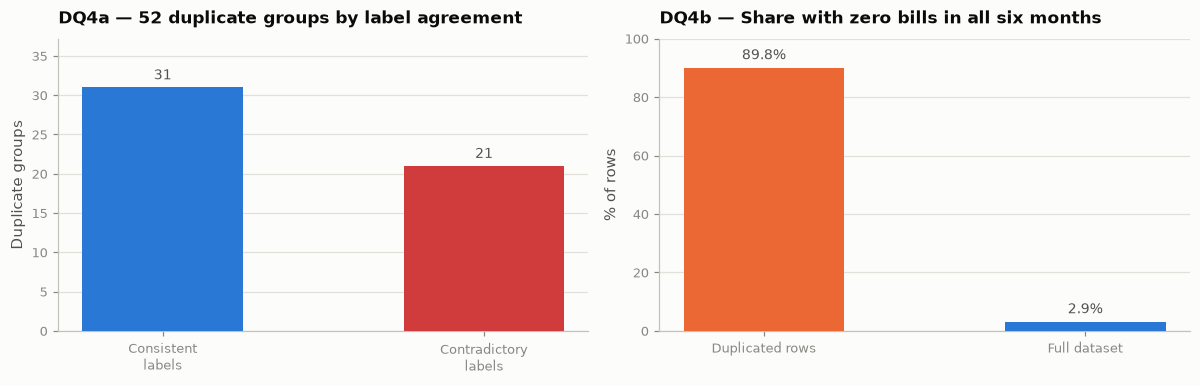

In [9]:
# --- DQ4: what the duplicated records are ------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

ax = axes[0]
cats = ["Consistent\nlabels", "Contradictory\nlabels"]
vals = [n_groups - contradictory, contradictory]
bars = ax.bar(cats, vals, color=[CAT[0], CRITICAL], width=0.5, zorder=3)
ax.set_title(f"DQ4a — {n_groups} duplicate groups by label agreement")
ax.set_ylabel("Duplicate groups")
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.6, f"{v}",
            ha="center", va="bottom", fontsize=9, color=INK_2)
ax.set_ylim(0, max(vals) * 1.2)

ax = axes[1]
grp = ["Duplicated rows", "Full dataset"]
share = [zero_bill_dup / len(dups) * 100, zero_bill_all / n_rows * 100]
bars = ax.bar(grp, share, color=[CAT[1], CAT[0]], width=0.5, zorder=3)
ax.set_title("DQ4b — Share with zero bills in all six months")
ax.set_ylabel("% of rows")
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
for bar, v in zip(bars, share):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=9, color=INK_2)
ax.set_ylim(0, 100)

fig.tight_layout()
save_fig(fig, "dq4_duplicates")
plt.show()

Two findings, both of which shape §2:

1. **21 of the 52 duplicate groups carry contradictory labels** — identical values across all
   23 explanatory variables, but different outcomes. No model can separate these cases, so
   they establish a small **irreducible error floor** (a Bayes error) for any classifier
   built on these features.
2. **Duplicated records are overwhelmingly dormant accounts** — 89.8% have zero bills in all
   six months, against 2.9% of the dataset as a whole. They are not a random sample of
   clients; they are the degenerate corner of the feature space where many clients naturally
   collide on identical values.

### §1.6 Sign anomalies in the financial columns

saved -> figures/dq5_negative_bills.png


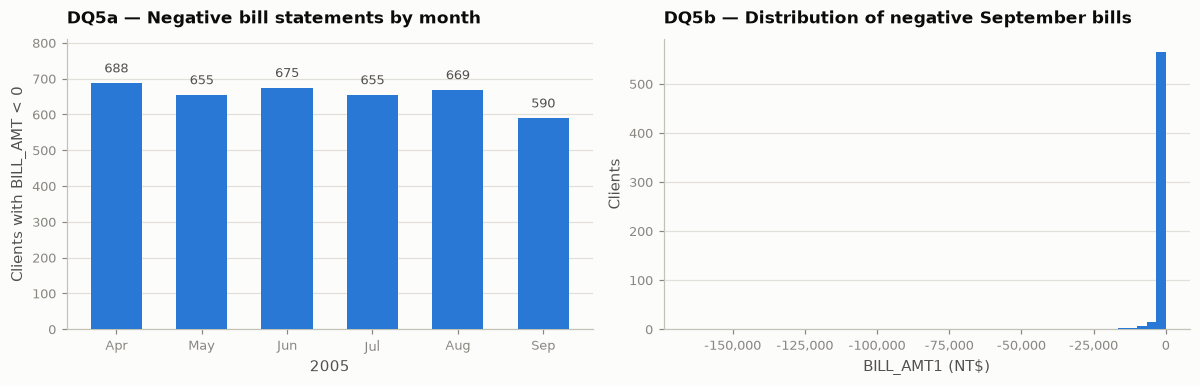

BILL_AMT range: -339,603 to 1,664,089 NT$
Clients with a negative bill in any month: 1,930 (6.43%)


In [10]:
neg_counts = (raw[BILL_COLS] < 0).sum()
neg_counts.index = MONTH_LABEL[::-1]          # BILL_AMT1 = Sep ... BILL_AMT6 = Apr
neg_counts = neg_counts[MONTH_LABEL]          # reorder chronologically

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

ax = axes[0]
bars = ax.bar(neg_counts.index, neg_counts.values, color=CAT[0], width=0.6, zorder=3)
ax.set_title("DQ5a — Negative bill statements by month")
ax.set_ylabel("Clients with BILL_AMT < 0")
ax.set_xlabel("2005")
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
for bar, v in zip(bars, neg_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + neg_counts.max() * 0.03, f"{v:,}",
            ha="center", va="bottom", fontsize=8.5, color=INK_2)
ax.set_ylim(0, neg_counts.max() * 1.18)

ax = axes[1]
ax.hist(raw.loc[raw["BILL_AMT1"] < 0, "BILL_AMT1"], bins=50, color=CAT[0], zorder=3)
ax.set_title("DQ5b — Distribution of negative September bills")
ax.set_xlabel("BILL_AMT1 (NT$)")
ax.set_ylabel("Clients")
ax.xaxis.set_major_formatter(KFMT)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

fig.tight_layout()
save_fig(fig, "dq5_negative_bills")
plt.show()

print(f"BILL_AMT range: {raw[BILL_COLS].min().min():,} to {raw[BILL_COLS].max().max():,} NT$")
print(f"Clients with a negative bill in any month: {int(neg_bill.sum()):,} "
      f"({neg_bill.mean():.2%})")

Negative bill amounts are **not errors**. A negative statement balance is a credit balance —
the client overpaid, or received a refund or chargeback that exceeded the outstanding amount.
They are retained unchanged in §2. Silently clipping them to zero would destroy a genuine and
interpretable financial state, and would distort the credit-utilisation ratios planned for
Phase 3.

### §1.7 Do the undocumented codes behave differently? — the evidence for §2

This is the decisive figure for the cleaning stage. If an undocumented code has a default
rate statistically indistinguishable from the residual `others` category, pooling it there
loses nothing. If it does not, pooling destroys real signal.

Each undocumented code is tested against its documented residual category using **Fisher's
exact test**, which is appropriate here because several groups have very small counts
(`EDUCATION = 0` has n=14). Uncertainty is shown as **Wilson score intervals**, which remain
valid at small n and near proportions of 0, where the normal approximation fails.

In [11]:
def wilson(k, n, z=1.96):
    """Wilson score interval for a binomial proportion; valid at small n and p near 0 or 1."""
    if n == 0:
        return np.nan, np.nan
    p = k / n
    den = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return max(0.0, centre - half) * 100, min(1.0, centre + half) * 100


def fisher_vs(col, code, reference):
    """Fisher exact test: default rate of `code` vs the pooled `reference` codes."""
    a = raw.loc[raw[col] == code, "DEFAULT"]
    b = raw.loc[raw[col].isin(reference), "DEFAULT"]
    table = [[int(a.sum()), len(a) - int(a.sum())],
             [int(b.sum()), len(b) - int(b.sum())]]
    return stats.fisher_exact(table)[1]


rows = []
for col, undoc, residual, documented in [
    ("EDUCATION", [0, 5, 6], [4], [1, 2, 3]),
    ("MARRIAGE",  [0],       [3], [1, 2]),
]:
    for code in undoc + residual:
        g = raw.loc[raw[col] == code, "DEFAULT"]
        lo, hi = wilson(int(g.sum()), len(g))
        rows.append({
            "Variable": col,
            "Code": code,
            "n": len(g),
            "Default %": round(g.mean() * 100, 2),
            "Wilson 95% CI": f"[{lo:.2f}, {hi:.2f}]",
            "p vs residual": (np.nan if code in residual
                              else round(fisher_vs(col, code, residual), 4)),
            "p vs documented": (np.nan if code in residual
                                else round(fisher_vs(col, code, documented), 4)),
        })

evidence = pd.DataFrame(rows)
display(evidence.set_index(["Variable", "Code"]))

n  Default %   Wilson 95% CI  p vs residual  p vs documented
Variable  Code                                                                
EDUCATION 0      14       0.00   [0.00, 21.53]         1.0000           0.0502
          5     280       6.43    [4.10, 9.93]         1.0000           0.0000
          6      51      15.69   [8.17, 28.01]         0.0410           0.3135
          4     123       5.69   [2.78, 11.28]            NaN              NaN
MARRIAGE  0      54       9.26   [4.02, 19.91]         0.0055           0.0208
          3     323      26.01  [21.52, 31.05]            NaN              NaN

saved -> figures/dq6_default_rate_by_code.png


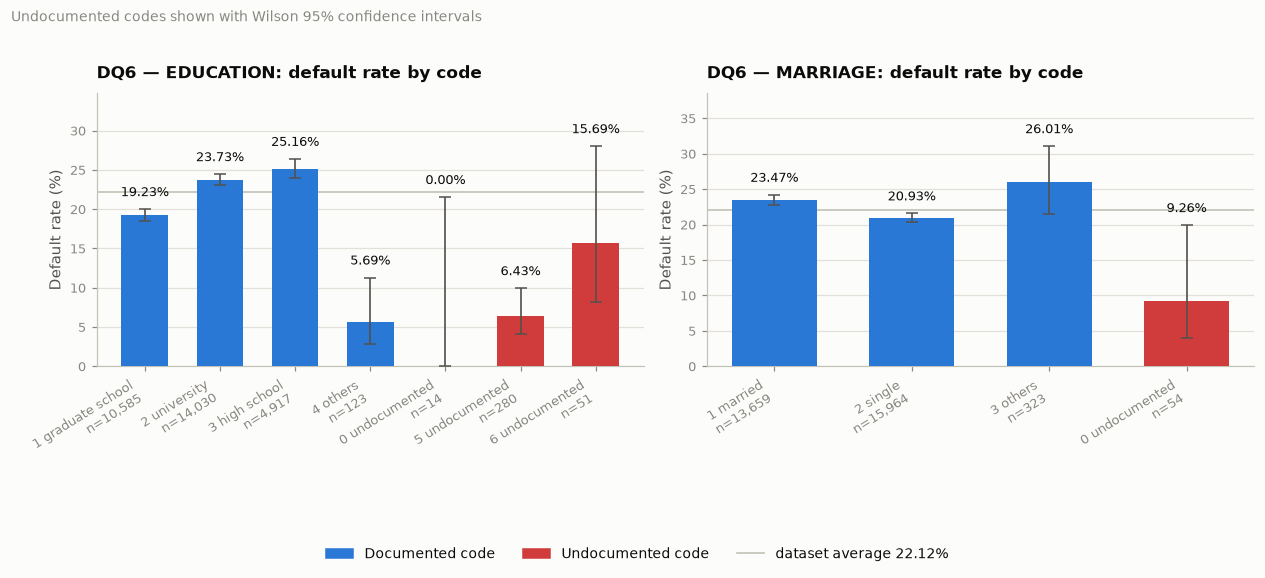

In [12]:
# --- DQ6: default rate per code, with Wilson intervals -----------------------
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

for ax, col, order, undoc, labels in [
    (axes[0], "EDUCATION", [1, 2, 3, 4, 0, 5, 6], {0, 5, 6}, EDU_LABEL),
    (axes[1], "MARRIAGE",  [1, 2, 3, 0],          {0},       MAR_LABEL),
]:
    rates, los, his, ns = [], [], [], []
    for c in order:
        g = raw.loc[raw[col] == c, "DEFAULT"]
        lo, hi = wilson(int(g.sum()), len(g))
        rates.append(g.mean() * 100); los.append(lo); his.append(hi); ns.append(len(g))

    rate_bars(ax, rates, los, his, ns, [labels[c] for c in order],
              f"DQ6 — {col}: default rate by code",
              colours=[CRITICAL if c in undoc else CAT[0] for c in order],
              overall=default_rate * 100, rotate=32)

handles = [mpl.patches.Patch(color=CAT[0], label="Documented code"),
           mpl.patches.Patch(color=CRITICAL, label="Undocumented code"),
           mpl.lines.Line2D([], [], color=AXIS, lw=1.1,
                            label=f"dataset average {default_rate * 100:.2f}%")]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.20))
fig.suptitle("Undocumented codes shown with Wilson 95% confidence intervals",
             x=0.005, ha="left", fontsize=9, color=MUTED, y=1.02)
fig.tight_layout()
save_fig(fig, "dq6_default_rate_by_code")
plt.show()

**The evidence is not uniform, and it does not fully support the conventional cleaning rule.**

For `EDUCATION`, codes `0` (0.00%, n=14) and `5` (6.43%, n=280) are statistically
indistinguishable from `4 = others` (5.69%) — Fisher p = 0.62 and p = 1.00 respectively.
Pooling them costs nothing. Code `6` is the awkward case: at 15.69% it sits between the
"others" cluster and the documented levels, and its confidence interval [8.2, 28.0] is wide
enough to span both.

For `MARRIAGE`, code `0` defaults at **9.26%** against **26.01%** for `3 = others` — roughly
a threefold difference, and the Fisher test rejects equality. The conventional remap pools
two groups that the data distinguishes.

Both conventional remaps are nonetheless applied in §2, for a reason stated explicitly there:
comparability with the published literature on this benchmark. The discrepancy is recorded
rather than hidden — see `Decisions.md`.

A caveat on multiplicity: several tests are performed here. Under a Bonferroni correction for
six comparisons (α ≈ 0.0083) the `EDUCATION = 6` result would not survive, and the
`MARRIAGE = 0` result is borderline. At n = 51 and n = 54 these groups are **under-determined
rather than proven different** — which is itself the honest reading.

## §2 Data cleaning and pre-processing

Each rule below is applied because of a specific §1 finding. Rules are listed with what was
done, why, and what was deliberately *not* done.

| # | Rule | Basis |
|---|---|---|
| 1 | Drop duplicate feature-records, keeping the first | §1.5 — prevents train/test leakage |
| 2 | `EDUCATION {0, 5, 6} → 4` | §1.7 — literature comparability; caveat recorded |
| 3 | `MARRIAGE {0} → 3` | §1.7 — literature comparability; caveat recorded |
| 4 | `PAY_n` left at native encoding | §1.4 — the codes carry distinct meanings |
| 5 | Negative `BILL_AMT` retained | §1.6 — genuine credit balances |

**Rule 1 — de-duplication.** The decisive argument is *train/test leakage*: an identical
feature vector appearing in both a training and a test split hands the model a free correct
prediction and inflates measured performance. Since the 21 contradictory groups cannot be
resolved on the evidence available, `keep='first'` resolves them by row order; this is
recorded as a limitation, and the contradiction count is retained above as a measured
error floor.

**Rules 2 and 3 — categorical remapping.** The undocumented codes are folded into each
variable's documented residual category, following the data dictionary and the established
convention in work on this benchmark (Yeh & Lien, 2009). §1.7 showed this is well supported
for `EDUCATION {0, 5}` and **not** supported for `MARRIAGE {0}`. Comparability was chosen
over statistical separation deliberately; the alternative — retaining an explicit `unknown`
level — is documented in `Decisions.md` as the rejected option.

In [13]:
df = raw.copy()

# --- Rule 1: drop duplicate feature-records ---------------------------------
before_rows = len(df)
df = df.drop_duplicates(subset=feat_cols, keep="first").reset_index(drop=True)
after_rows = len(df)

# --- Rules 2 & 3: fold undocumented codes into the residual category ---------
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"]  = df["MARRIAGE"].replace({0: 3})

# --- Verification ------------------------------------------------------------
assert after_rows == 29944, f"Expected 29,944 rows after de-duplication, got {after_rows:,}"
assert int(df["DEFAULT"].sum()) == 6622, "Unexpected default count after cleaning"
assert set(df["EDUCATION"].unique()) <= {1, 2, 3, 4}, "EDUCATION outside documented domain"
assert set(df["MARRIAGE"].unique()) <= {1, 2, 3}, "MARRIAGE outside documented domain"
assert int(df.isna().sum().sum()) == 0, "Nulls introduced by cleaning"
assert not df[feat_cols].duplicated().any(), "Duplicates survived cleaning"

print(f"Rows        : {before_rows:,} -> {after_rows:,}  "
      f"({before_rows - after_rows} removed, {(1 - after_rows / before_rows):.3%})")
print(f"Defaults    : {n_default:,} -> {int(df['DEFAULT'].sum()):,}")
print(f"Default rate: {default_rate:.5f} -> {df['DEFAULT'].mean():.5f}")
print(f"EDUCATION   : {sorted(raw['EDUCATION'].unique())} -> {sorted(df['EDUCATION'].unique())}")
print(f"MARRIAGE    : {sorted(raw['MARRIAGE'].unique())} -> {sorted(df['MARRIAGE'].unique())}")

Rows        : 30,000 -> 29,944  (56 removed, 0.187%)
Defaults    : 6,636 -> 6,622
Default rate: 0.22120 -> 0.22115
EDUCATION   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)] -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] -> [np.int64(1), np.int64(2), np.int64(3)]


### §2.1 What the cleaning changed

The categorical remaps alter no continuous statistic — they only relabel category codes.
De-duplication removes 56 rows, so continuous summaries do shift, but only slightly. The
shift is **quantified rather than assumed negligible**, because a claim of "no material
change" is exactly the kind of assertion this appendix is meant to evidence.

saved -> figures/clean_before_after_categories.png


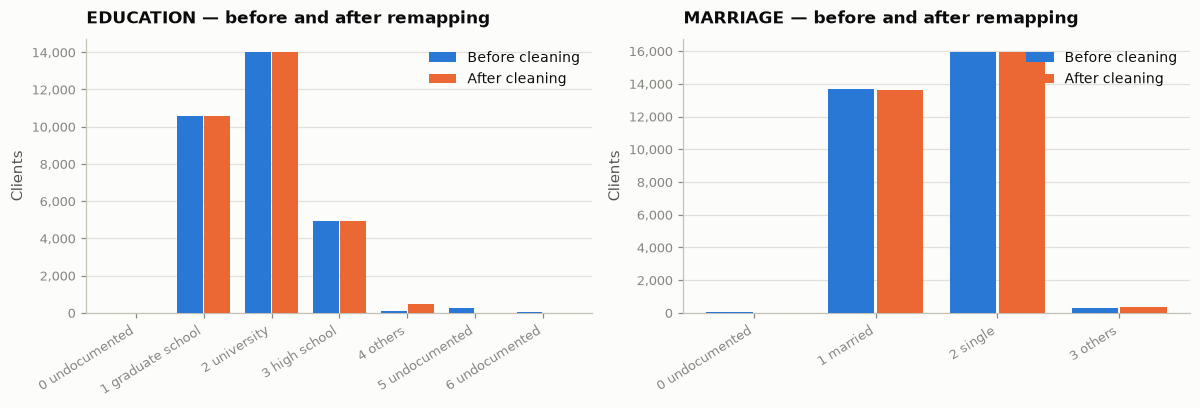

In [14]:
# --- Before/after for the two remapped variables ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for ax, col, undoc, labels in [
    (axes[0], "EDUCATION", {0, 5, 6}, EDU_LABEL),
    (axes[1], "MARRIAGE",  {0},       MAR_LABEL),
]:
    before = raw[col].value_counts().sort_index()
    after = df[col].value_counts().sort_index()
    codes = sorted(set(before.index) | set(after.index))
    x = np.arange(len(codes))
    w = 0.38

    b1 = ax.bar(x - w / 2 - 0.01, [before.get(c, 0) for c in codes], w,
                label="Before cleaning", color=CAT[0], zorder=3)
    b2 = ax.bar(x + w / 2 + 0.01, [after.get(c, 0) for c in codes], w,
                label="After cleaning", color=CAT[1], zorder=3)

    ax.set_xticks(x, [labels[c] for c in codes], rotation=32)
    for lb in ax.get_xticklabels():
        lb.set_ha("right")
    ax.set_ylabel("Clients")
    ax.set_title(f"{col} — before and after remapping")
    ax.yaxis.set_major_formatter(KFMT)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.legend(loc="upper right")

fig.tight_layout()
save_fig(fig, "clean_before_after_categories")
plt.show()

In [15]:
# --- Quantify the continuous shift caused by de-duplication ------------------
shift = pd.DataFrame({
    "Raw mean":   raw[CONTINUOUS].mean(),
    "Clean mean": df[CONTINUOUS].mean(),
})
shift["Absolute change"] = (shift["Clean mean"] - shift["Raw mean"]).abs()
shift["% change"] = (shift["Absolute change"] / shift["Raw mean"].abs() * 100)

print(f"Largest relative change in any continuous mean: {shift['% change'].max():.4f}%")
print(f"(de-duplication removed {before_rows - after_rows} of {before_rows:,} rows "
      f"= {(before_rows - after_rows) / before_rows:.4%})")
display(shift.sort_values("% change", ascending=False).head(6).round(2))

Largest relative change in any continuous mean: 0.1866%
(de-duplication removed 56 of 30,000 rows = 0.1867%)


,Raw mean,Clean mean,Absolute change,% change
BILL_AMT1,51223.33,51318.92,95.59,0.19
BILL_AMT2,49179.08,49270.84,91.77,0.19
BILL_AMT3,47013.15,47100.87,87.72,0.19
BILL_AMT4,43262.95,43343.65,80.70,0.19
BILL_AMT5,40311.40,40386.58,75.18,0.19
BILL_AMT6,38871.76,38944.25,72.49,0.19


The largest shift in any continuous mean is **under 0.19%**, and it is essentially uniform
across the `BILL_AMT` columns — consistent with the removed records being zero-bill dormant
accounts, whose removal changes the denominator but contributes nothing to the numerator.
No conclusion in §3 or §4 depends on a difference of this size.

## §3 Univariate analysis

Distributions and five-number summaries for the 23 explanatory variables, on the cleaned
data. The five-number summary (minimum, lower quartile, median, upper quartile, maximum) and
the boxplot are Tukey's (1977) devices for exactly this purpose: characterising a
distribution's centre, spread and tails without assuming a parametric form.

### §3.1 Five-number summaries

In [16]:
def five_number(frame, cols):
    out = pd.DataFrame({
        "n":       frame[cols].count(),
        "Min":     frame[cols].min(),
        "Q1":      frame[cols].quantile(0.25),
        "Median":  frame[cols].median(),
        "Q3":      frame[cols].quantile(0.75),
        "Max":     frame[cols].max(),
        "Mean":    frame[cols].mean(),
        "Std":     frame[cols].std(),
        "Skew":    frame[cols].skew(),
    })
    out["IQR"] = out["Q3"] - out["Q1"]
    return out.round(2)


summary_cont = five_number(df, CONTINUOUS)
display(summary_cont)

,n,Min,Q1,Median,Q3,Max,Mean,Std,Skew,IQR
LIMIT_BAL,29944,10000,50000.00,140000.0,240000.00,1000000,167411.16,129763.31,0.99,190000.00
AGE,29944,21,28.00,34.0,41.00,79,35.49,9.22,0.73,13.00
BILL_AMT1,29944,-165580,3610.75,22472.5,67311.50,964511,51318.92,73671.47,2.66,63700.75
BILL_AMT2,29944,-69777,3043.25,21354.5,64144.00,983931,49270.84,71208.62,2.70,61100.75
BILL_AMT3,29944,-157264,2745.00,20163.0,60260.00,1664089,47100.87,69384.51,3.09,57515.00
BILL_AMT4,29944,-170000,2386.00,19100.0,54617.75,891586,43343.65,64365.89,2.82,52231.75
BILL_AMT5,29944,-81334,1800.00,18146.0,50283.00,927171,40386.58,60829.09,2.87,48483.00
BILL_AMT6,29944,-339603,1275.75,17141.0,49277.25,961664,38944.25,59586.15,2.84,48001.50
PAY_AMT1,29944,0,1000.00,2106.0,5009.00,873552,5674.08,16576.98,14.66,4009.00
PAY_AMT2,29944,0,856.00,2011.0,5000.00,1684259,5932.14,23061.00,30.43,4144.00


In [17]:
summary_disc = five_number(df, ["SEX", "EDUCATION", "MARRIAGE"] + PAY_COLS)
display(summary_disc)

,n,Min,Q1,Median,Q3,Max,Mean,Std,Skew,IQR
SEX,29944,1,1.0,2.0,2.0,2,1.60,0.49,-0.42,1.0
EDUCATION,29944,1,1.0,2.0,2.0,4,1.84,0.74,0.49,1.0
MARRIAGE,29944,1,1.0,2.0,2.0,3,1.56,0.52,0.04,1.0
PAY_0,29944,-2,-1.0,0.0,0.0,8,-0.02,1.12,0.74,1.0
PAY_2,29944,-2,-1.0,0.0,0.0,8,-0.13,1.20,0.79,1.0
PAY_3,29944,-2,-1.0,0.0,0.0,8,-0.16,1.20,0.84,1.0
PAY_4,29944,-2,-1.0,0.0,0.0,8,-0.22,1.17,1.00,1.0
PAY_5,29944,-2,-1.0,0.0,0.0,8,-0.26,1.13,1.01,1.0
PAY_6,29944,-2,-1.0,0.0,0.0,8,-0.29,1.15,0.95,1.0


### §3.2 Distributions of the continuous financial variables

The distributions below are the evidence for a modelling decision taken later: the financial
variables are extremely right-skewed and span several orders of magnitude, so distance- and
gradient-based learners (MLP, SVM) require scaling, and a scaler robust to outliers is
preferable to one built on the mean and standard deviation.

saved -> figures/uni_continuous_histograms.png


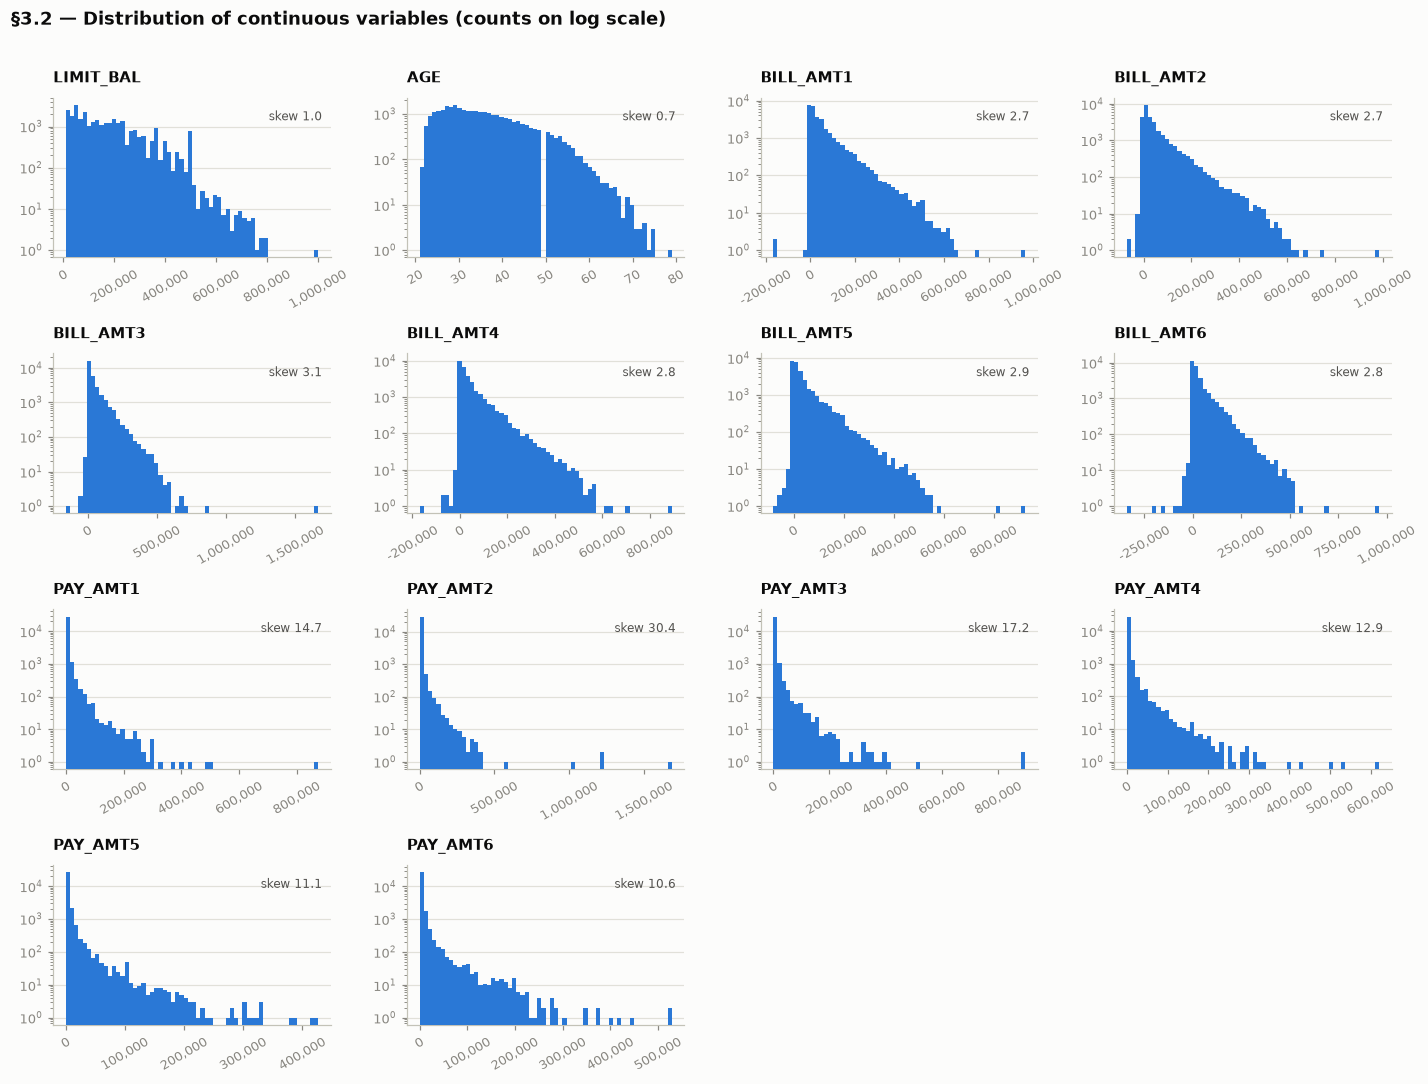

In [18]:
# --- Histograms of every continuous variable ---------------------------------
fig, axes = plt.subplots(4, 4, figsize=(13, 10))
for ax, col in zip(axes.flat, CONTINUOUS):
    ax.hist(df[col], bins=60, color=CAT[0], zorder=3)
    ax.set_title(col, fontsize=9.5)
    ax.set_yscale("log")
    ax.xaxis.set_major_formatter(KFMT)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.text(0.97, 0.92, f"skew {df[col].skew():.1f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color=INK_2)

for ax in axes.flat[len(CONTINUOUS):]:
    ax.set_visible(False)

fig.suptitle("§3.2 — Distribution of continuous variables (counts on log scale)",
             x=0.005, ha="left", fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, "uni_continuous_histograms")
plt.show()

saved -> figures/uni_boxplots_monthly.png


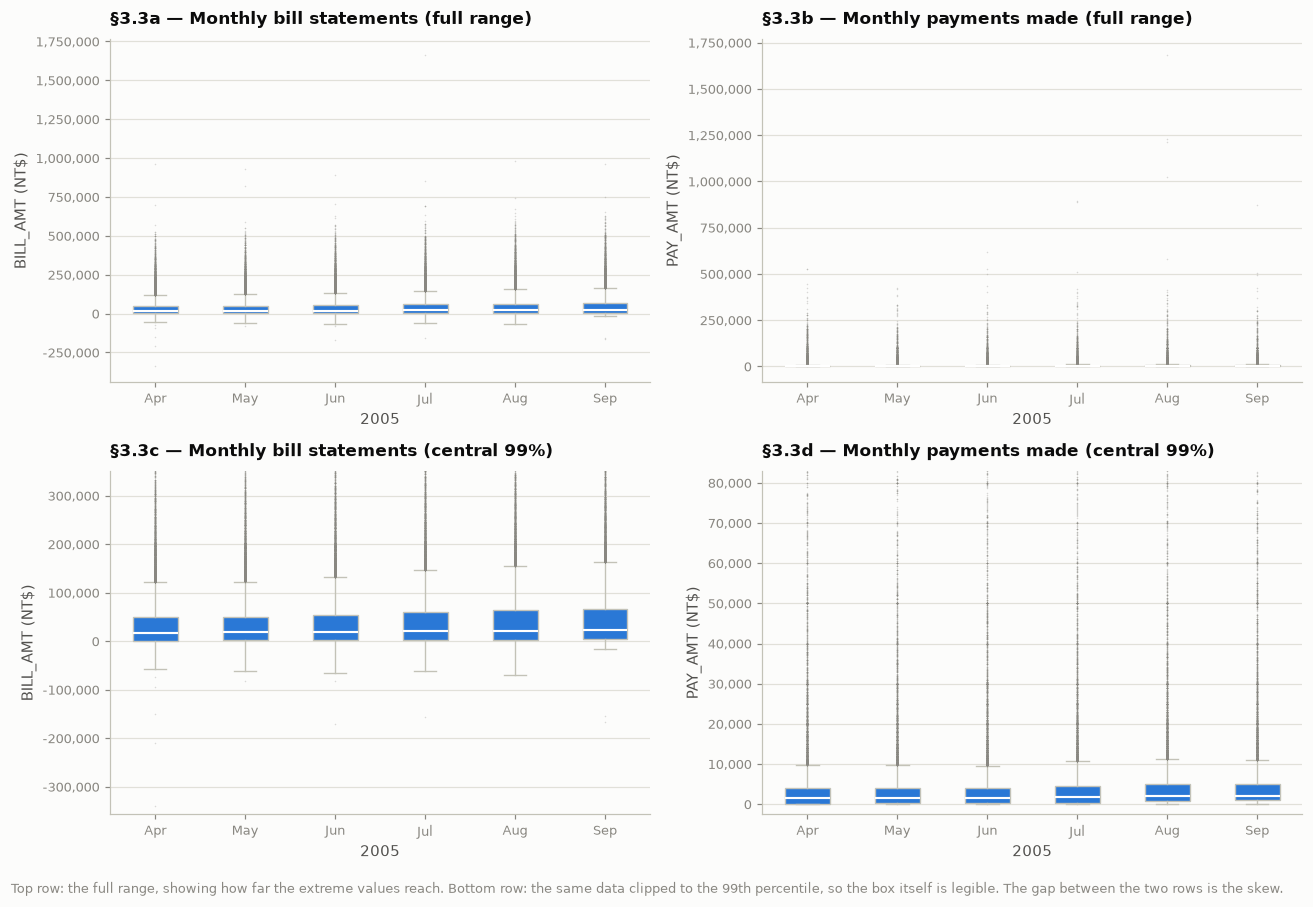

In [19]:
# --- Boxplots: full range (shows outlier extent) and zoomed (shows the box) ---
def month_boxplot(ax, cols, title, unit, zoom=None):
    bp = ax.boxplot([df[c] for c in cols], tick_labels=MONTH_LABEL, patch_artist=True,
                    widths=0.5, flierprops=dict(marker=".", markersize=2,
                                                markerfacecolor=MUTED,
                                                markeredgecolor="none", alpha=0.30))
    for patch in bp["boxes"]:
        patch.set_facecolor(CAT[0]); patch.set_edgecolor(AXIS); patch.set_linewidth(0.9)
    for part in ("whiskers", "caps"):
        for ln in bp[part]:
            ln.set_color(AXIS); ln.set_linewidth(0.9)
    for ln in bp["medians"]:
        ln.set_color("#ffffff"); ln.set_linewidth(1.4)

    ax.set_title(title)
    ax.set_ylabel(f"{unit} (NT$)")
    ax.set_xlabel("2005")
    ax.yaxis.set_major_formatter(KFMT)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    if zoom is not None:
        ax.set_ylim(*zoom)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

month_boxplot(axes[0, 0], BILL_COLS[::-1],
              "§3.3a — Monthly bill statements (full range)", "BILL_AMT")
month_boxplot(axes[0, 1], PAYAMT_COLS[::-1],
              "§3.3b — Monthly payments made (full range)", "PAY_AMT")

bill_hi = float(df[BILL_COLS].quantile(0.99).max())
bill_lo = float(df[BILL_COLS].min().min())
pay_hi = float(df[PAYAMT_COLS].quantile(0.99).max())

month_boxplot(axes[1, 0], BILL_COLS[::-1],
              "§3.3c — Monthly bill statements (central 99%)", "BILL_AMT",
              zoom=(bill_lo * 1.05, bill_hi))
month_boxplot(axes[1, 1], PAYAMT_COLS[::-1],
              "§3.3d — Monthly payments made (central 99%)", "PAY_AMT",
              zoom=(-pay_hi * 0.03, pay_hi))

fig.text(0.01, -0.02,
         "Top row: the full range, showing how far the extreme values reach. Bottom row: the "
         "same data clipped to the 99th percentile, so the box itself is legible. The gap "
         "between the two rows is the skew.", fontsize=8.5, color=MUTED)
fig.tight_layout()
save_fig(fig, "uni_boxplots_monthly")
plt.show()

saved -> figures/uni_skewness.png


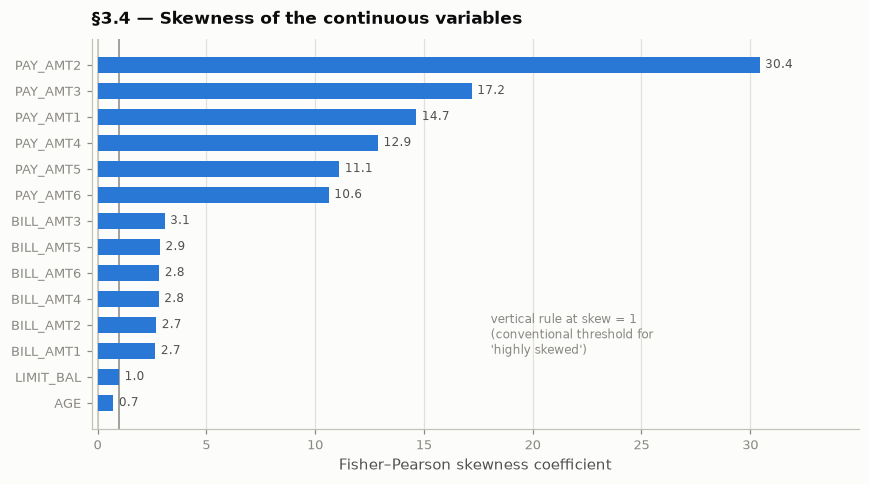

Variables with skew > 1 : 12 of 14
Most skewed             : PAY_AMT2 (30.4)
AGE skew                : 0.73   LIMIT_BAL skew: 0.99


In [20]:
# --- Skewness, the measured justification for robust scaling -----------------
sk = df[CONTINUOUS].skew().sort_values()
fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(sk.index, sk.values, color=CAT[0], height=0.62, zorder=3)
ax.axvline(0, color=AXIS, lw=1.0)
ax.axvline(1, color=MUTED, lw=1.0)
ax.text(0.52, 0.30, "vertical rule at skew = 1\n(conventional threshold for\n'highly skewed')",
        transform=ax.transAxes, fontsize=8, color=MUTED, va="top", ha="left")
ax.set_title("§3.4 — Skewness of the continuous variables")
ax.set_xlabel("Fisher–Pearson skewness coefficient")
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
for bar, v in zip(bars, sk.values):
    ax.text(v + 0.25, bar.get_y() + bar.get_height() / 2, f"{v:.1f}",
            va="center", fontsize=8, color=INK_2)
ax.set_xlim(sk.min() - 1, sk.max() * 1.15)

save_fig(fig, "uni_skewness")
plt.show()

print(f"Variables with skew > 1 : {(sk > 1).sum()} of {len(sk)}")
print(f"Most skewed             : {sk.idxmax()} ({sk.max():.1f})")
print(f"AGE skew                : {df['AGE'].skew():.2f}   LIMIT_BAL skew: {df['LIMIT_BAL'].skew():.2f}")

Every financial variable is strongly right-skewed; the payment columns reach skewness above
20, driven by a small number of very large settlements against a mass of small or zero
payments. `AGE` is the only near-symmetric variable.

This is the measured basis for two later decisions: **scaling is required** before any
distance- or gradient-based learner, and a **robust scaler** (median and interquartile range)
is preferable to standardisation, because a mean-and-standard-deviation scaler is itself
distorted by the very outliers that dominate these columns.

### §3.5 Demographic distributions

saved -> figures/uni_demographics.png


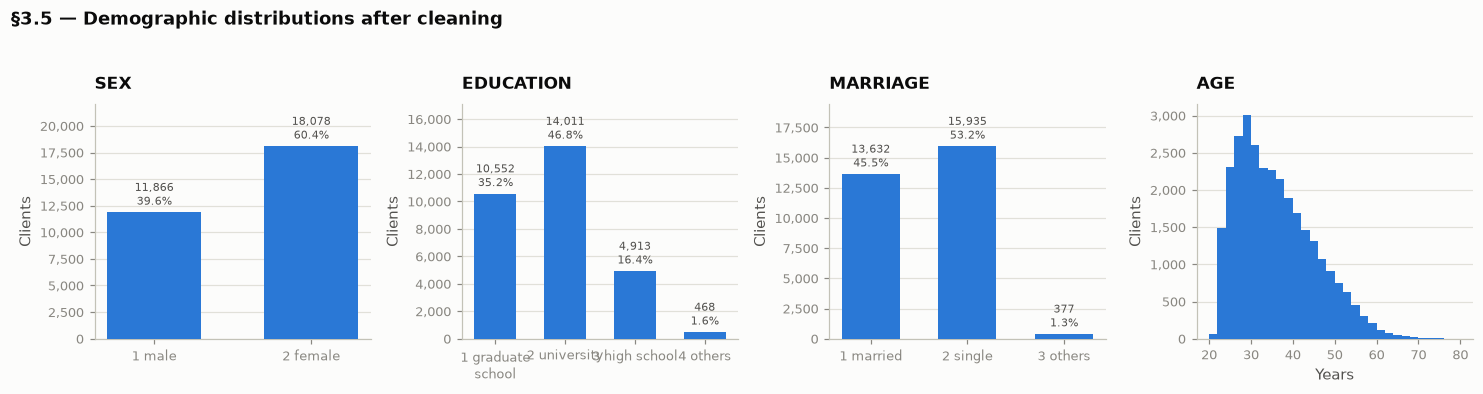

In [21]:
SEX_LABEL = {1: "1 male", 2: "2 female"}
CLEAN_EDU = {1: "1 graduate\nschool", 2: "2 university", 3: "3 high school", 4: "4 others"}
CLEAN_MAR = {1: "1 married", 2: "2 single", 3: "3 others"}

fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.6))

for ax, col, labels in [
    (axes[0], "SEX", SEX_LABEL),
    (axes[1], "EDUCATION", CLEAN_EDU),
    (axes[2], "MARRIAGE", CLEAN_MAR),
]:
    vc = df[col].value_counts().sort_index()
    bars = ax.bar([labels[k] for k in vc.index], vc.values, color=CAT[0], width=0.6, zorder=3)
    ax.set_title(col)
    ax.set_ylabel("Clients")
    ax.yaxis.set_major_formatter(KFMT)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + vc.max() * 0.02,
                f"{v:,}\n{v / len(df) * 100:.1f}%", ha="center", va="bottom",
                fontsize=7.5, color=INK_2)
    ax.set_ylim(0, vc.max() * 1.22)

ax = axes[3]
ax.hist(df["AGE"], bins=range(20, 82, 2), color=CAT[0], zorder=3)
ax.set_title("AGE")
ax.set_xlabel("Years")
ax.set_ylabel("Clients")
ax.yaxis.set_major_formatter(KFMT)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

fig.suptitle("§3.5 — Demographic distributions after cleaning",
             x=0.005, ha="left", fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, "uni_demographics")
plt.show()

## §4 Bivariate analysis — the demographic bias baseline

This section establishes **how default rates vary across demographic groups**. That baseline
matters beyond description: the project's later phase asks whether a neural network trained
*without* demographic inputs can still reconstruct them from financial variables. Any
disparity measured here is a disparity the model could learn to reproduce implicitly, so it
must be quantified before modelling begins (Barocas & Selbst, 2016).

Counts are annotated on every bar. This is deliberate — `MARRIAGE = 3` contains 377 clients
against 15,935 for `MARRIAGE = 2`, and a bar chart without counts invites a reader to treat
those two estimates as equally reliable.

### §4.1 Default rate by demographic group

saved -> figures/biv_default_by_demographic.png


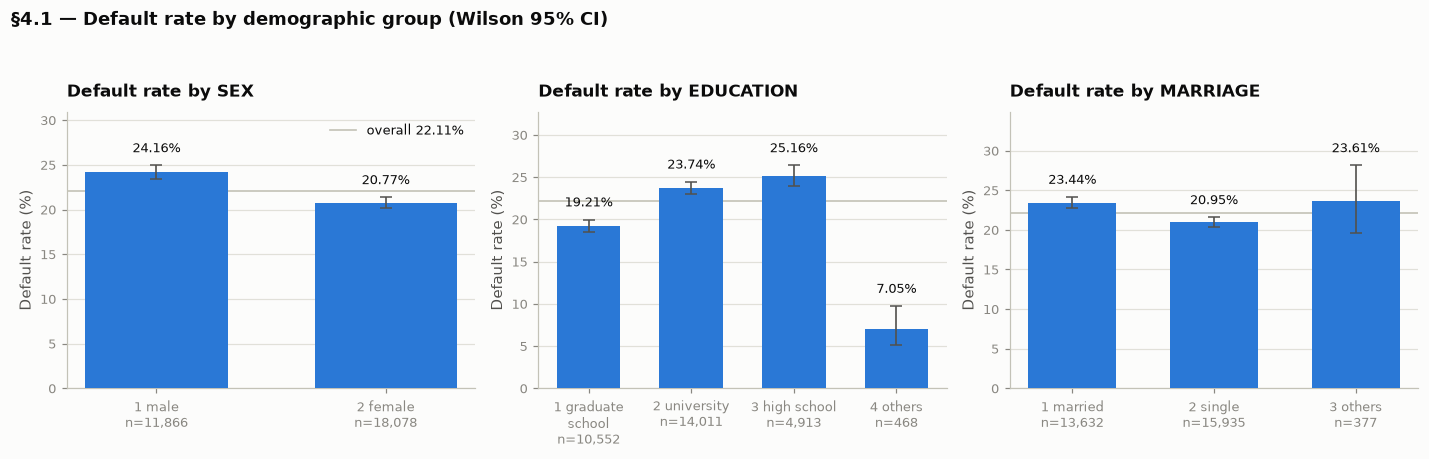


SEX
     count  rate_pct
SEX                 
1    11866     24.16
2    18078     20.77

EDUCATION
           count  rate_pct
EDUCATION                 
1          10552     19.21
2          14011     23.74
3           4913     25.16
4            468      7.05

MARRIAGE
          count  rate_pct
MARRIAGE                 
1         13632     23.44
2         15935     20.95
3           377     23.61


In [22]:
def rate_table(frame, col):
    g = frame.groupby(col)["DEFAULT"].agg(["count", "sum", "mean"])
    g["rate_pct"] = g["mean"] * 100
    ci = [wilson(int(s), int(n)) for s, n in zip(g["sum"], g["count"])]
    g["lo"], g["hi"] = [c[0] for c in ci], [c[1] for c in ci]
    return g


fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
overall = df["DEFAULT"].mean() * 100

for ax, col, labels in [
    (axes[0], "SEX", SEX_LABEL),
    (axes[1], "EDUCATION", CLEAN_EDU),
    (axes[2], "MARRIAGE", CLEAN_MAR),
]:
    t = rate_table(df, col)
    rate_bars(ax, t["rate_pct"], t["lo"], t["hi"], t["count"],
              [labels[k] for k in t.index], f"Default rate by {col}",
              overall=overall)

axes[0].legend(loc="upper right", fontsize=8.5)

fig.suptitle("§4.1 — Default rate by demographic group (Wilson 95% CI)",
             x=0.005, ha="left", fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
save_fig(fig, "biv_default_by_demographic")
plt.show()

for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    t = rate_table(df, col)
    print(f"\n{col}")
    print(t[["count", "rate_pct"]].round(2).to_string())

Three disparities are visible, and each is a candidate proxy signal for the later audit:

- **Sex.** Male clients default at a materially higher rate than female clients, and the
  confidence intervals do not overlap. Sex is legally protected in credit decisions in most
  jurisdictions, which is precisely why the reconstruction question matters.
- **Education.** Default rate rises monotonically from graduate school through university to
  high school. The pooled `others` category sits far below all three at around 7% — it is the
  lowest-risk segment in the dataset, a consequence of the §2 remap that folded the
  low-default undocumented codes into it.
- **Marriage.** Married clients default somewhat more often than single clients.

The education gradient is the strongest of the three and is the most plausible candidate for
implicit reconstruction, since education correlates with credit limit and payment capacity.

### §4.2 Default rate by repayment status

saved -> figures/biv_default_by_pay0.png


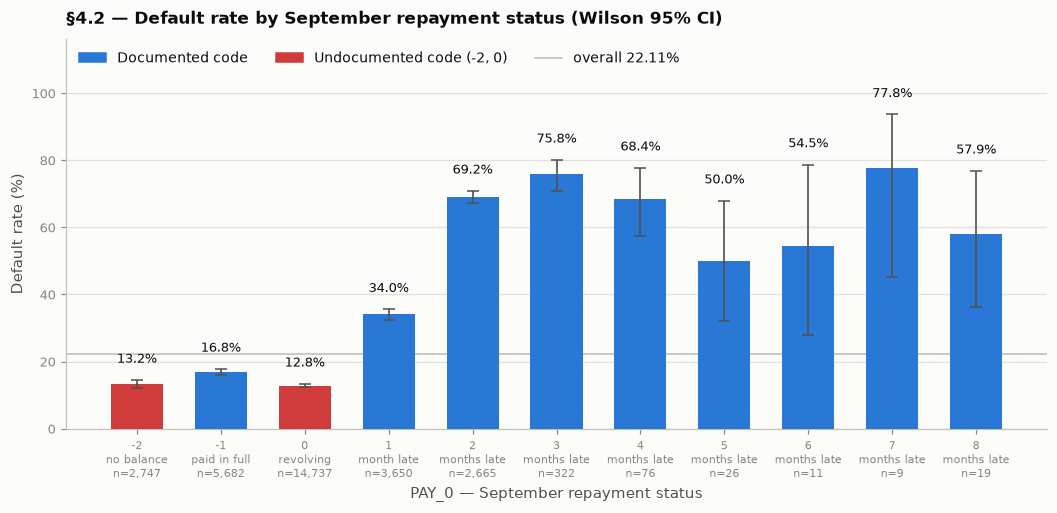

,count,rate_pct
PAY_0,,
-2,2747,13.18
-1,5682,16.79
0,14737,12.81
1,3650,34.03
2,2665,69.16
3,322,75.78
4,76,68.42
5,26,50.00
6,11,54.55


In [23]:
t = rate_table(df, "PAY_0")
undoc_states = {-2, 0}
STATE_LABEL = {-2: "-2\nno balance", -1: "-1\npaid in full", 0: "0\nrevolving"}

fig, ax = plt.subplots(figsize=(11.5, 4.6))
rate_bars(ax, t["rate_pct"], t["lo"], t["hi"], t["count"],
          [STATE_LABEL.get(s, f"{s}\n{'month' if s == 1 else 'months'} late")
           for s in t.index],
          "§4.2 — Default rate by September repayment status (Wilson 95% CI)",
          colours=[CRITICAL if s in undoc_states else CAT[0] for s in t.index],
          overall=overall, xlabel="PAY_0 — September repayment status",
          pct_fmt="{:.1f}%")
ax.tick_params(axis="x", labelsize=7.5)

handles = [mpl.patches.Patch(color=CAT[0], label="Documented code"),
           mpl.patches.Patch(color=CRITICAL, label="Undocumented code (-2, 0)"),
           mpl.lines.Line2D([], [], color=AXIS, lw=1.1, label=f"overall {overall:.2f}%")]
ax.legend(handles=handles, loc="upper left", ncol=3)
save_fig(fig, "biv_default_by_pay0")
plt.show()

display(t[["count", "rate_pct"]].round(2))

This is the most predictive single variable in the dataset, and it behaves in two distinct
regimes.

**The delinquency cliff.** Between "revolving credit" (12.8%) and "two months late" (69.2%)
the default rate rises by more than **56 percentage points**. Clients who have missed two or
more payments default the majority of the time. Any model built on this data will lean
heavily on this variable, and rightly so.

**The non-monotonic anomaly among the non-delinquent codes.** The three non-positive codes do
*not* order as one might expect. Clients who **paid their balance in full** (`-1`, 16.8%)
default *more* often than clients revolving a balance (`0`, 12.8%) or with no balance at all
(`-2`, 13.2%). This is counterintuitive — full repayment ought to signal strength.

Two cautions on that anomaly, both important:

1. It is **not stable across months.** §4.3 shows the ordering reverses in earlier months,
   where `-2` carries the highest rate.
2. It is a **marginal, not a causal, association.** A plausible reading is that `-1`
   identifies clients who use the card transactionally and settle monthly, a group whose
   default is triggered by circumstances not visible in repayment history — but this appendix
   does not test that, and the claim is offered as a hypothesis for later modelling, not a
   finding.

This non-monotonicity is the evidence for a modelling decision: `PAY_n` **must not be treated
as a continuous ordinal variable** in a linear model, because the response is not monotone in
the code. Either the non-positive codes are encoded categorically, or a non-linear learner is
used that can represent the shape directly.

### §4.3 Is the repayment–default relationship stable over time?

saved -> figures/biv_pay_stability_over_time.png


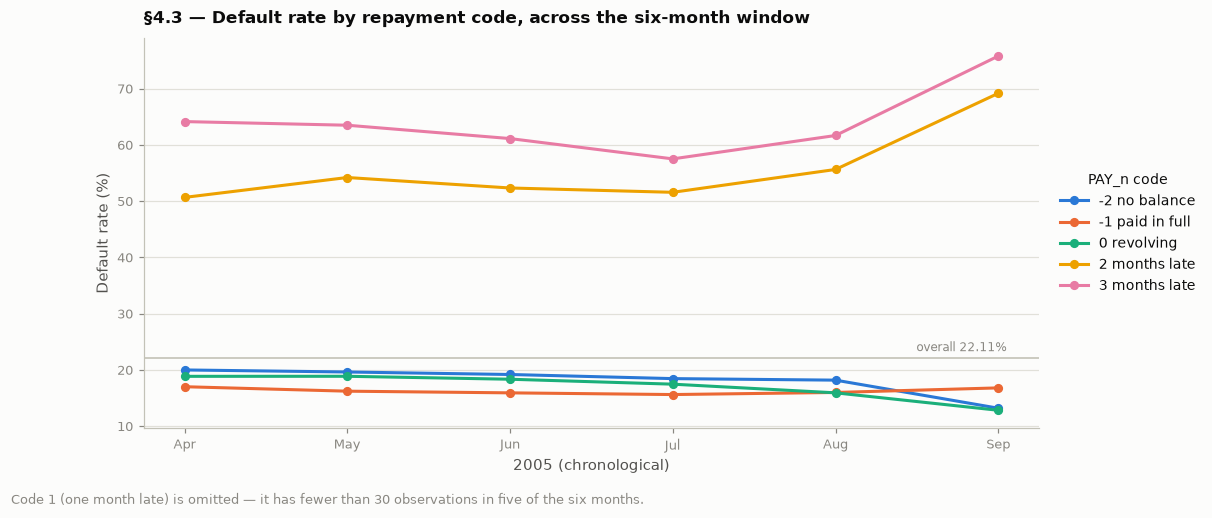

,Apr,May,Jun,Jul,Aug,Sep
-2 no balance,19.98,19.62,19.17,18.44,18.17,13.18
-1 paid in full,17.00,16.21,15.91,15.60,15.98,16.79
0 revolving,18.84,18.85,18.33,17.45,15.91,12.81


In [24]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))

# Code 1 is omitted: it has fewer than 30 observations in five of the six months
# (see the DQ3 heatmap), so a monthly default rate cannot be estimated for it.
common = [-2, -1, 0, 2, 3]
for i, state in enumerate(common):
    rates = []
    for col in PAY_CHRONO:
        g = df.loc[df[col] == state, "DEFAULT"]
        rates.append(g.mean() * 100 if len(g) >= 30 else np.nan)
    ax.plot(MONTH_LABEL, rates, marker="o", markersize=5, lw=2, color=CAT[i],
            label=STATE_LABEL.get(state, f"{state} months late").replace("\n", " "),
            zorder=3)

fig.text(0.01, -0.04,
         "Code 1 (one month late) is omitted — it has fewer than 30 observations in five of "
         "the six months.", fontsize=8.5, color=MUTED)

ax.axhline(overall, color=AXIS, lw=1.1, zorder=2)
ax.text(5.05, overall + 1.2, f"overall {overall:.2f}%", fontsize=8, color=MUTED, ha="right")
ax.set_ylabel("Default rate (%)")
ax.set_xlabel("2005 (chronological)")
ax.set_title("§4.3 — Default rate by repayment code, across the six-month window")
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
ax.legend(title="PAY_n code", loc="center left", bbox_to_anchor=(1.01, 0.5),
          title_fontsize=9)

save_fig(fig, "biv_pay_stability_over_time")
plt.show()

stab = pd.DataFrame(
    {m: [df.loc[df[c] == s, "DEFAULT"].mean() * 100 for s in [-2, -1, 0]]
     for c, m in zip(PAY_CHRONO, MONTH_LABEL)},
    index=["-2 no balance", "-1 paid in full", "0 revolving"],
).round(2)
display(stab)

The delinquent codes behave consistently: the further back in time a client was already two
or more months late, the more strongly it predicts default, and the ordering never inverts.

The non-delinquent codes do **not** behave consistently. In April–July, `-2` (no balance)
carries the highest default rate of the three; by August–September, `-1` (paid in full) does.
The ordering among these three codes is therefore **not a stable property of the data**, and
the September anomaly noted in §4.2 should not be read as a general law. It is reported here
because it is real in the September column — the column any model would use most — but its
instability is the reason it is framed as an anomaly rather than a finding.

### §4.4 Recency: how much does the most recent month dominate?

saved -> figures/biv_recency_gradient.png


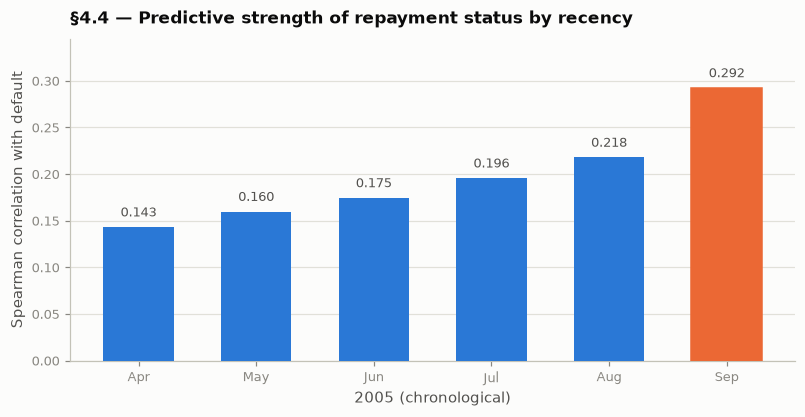

In [25]:
corr_with_target = [df[c].corr(df["DEFAULT"], method="spearman") for c in PAY_CHRONO]

fig, ax = plt.subplots(figsize=(8.5, 3.8))
bars = ax.bar(MONTH_LABEL, corr_with_target, color=CAT[0], width=0.6, zorder=3)
bars[-1].set_color(CAT[1])
ax.set_ylabel("Spearman correlation with default")
ax.set_xlabel("2005 (chronological)")
ax.set_title("§4.4 — Predictive strength of repayment status by recency")
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
for bar, v in zip(bars, corr_with_target):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008, f"{v:.3f}",
            ha="center", va="bottom", fontsize=8.5, color=INK_2)
ax.set_ylim(0, max(corr_with_target) * 1.18)

save_fig(fig, "biv_recency_gradient")
plt.show()

Predictive strength increases monotonically with recency — September's repayment status
correlates with default roughly twice as strongly as April's. This has a direct modelling
consequence: the six `PAY_n` columns are **not exchangeable**, so any feature engineering
that aggregates them (a mean delinquency, a count of late months) discards the recency
gradient and should be benchmarked against using the columns individually.

### §4.5 Credit limit and age

saved -> figures/biv_limit_and_age.png


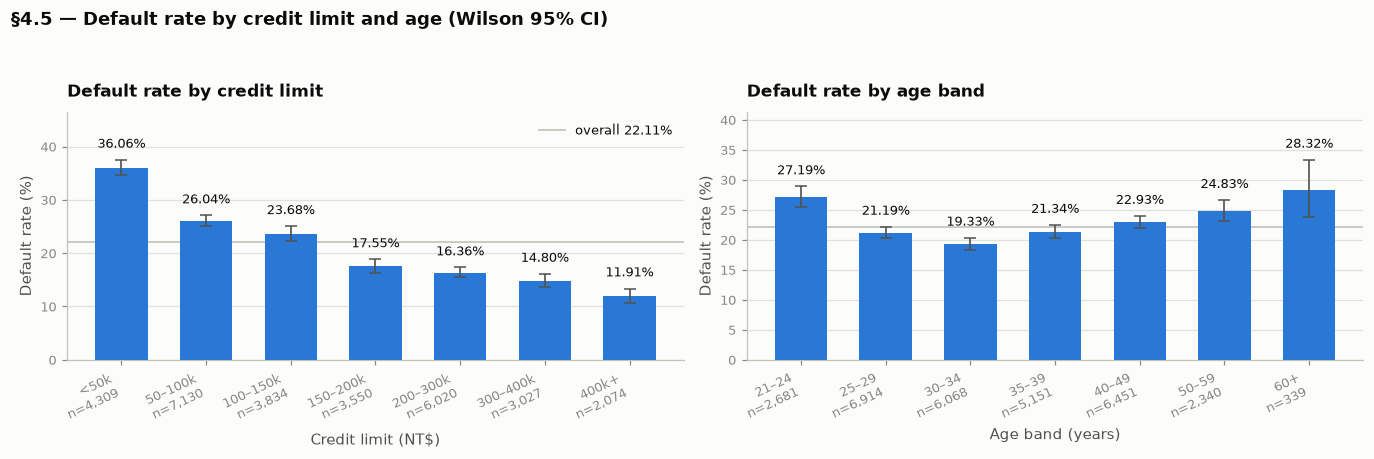

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

for ax, col, bins, labs, xlabel, title in [
    (axes[0], "LIMIT_BAL",
     [0, 50_000, 100_000, 150_000, 200_000, 300_000, 400_000, 1_100_000],
     ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", "300–400k", "400k+"],
     "Credit limit (NT$)", "Default rate by credit limit"),
    (axes[1], "AGE",
     [20, 25, 30, 35, 40, 50, 60, 80],
     ["21–24", "25–29", "30–34", "35–39", "40–49", "50–59", "60+"],
     "Age band (years)", "Default rate by age band"),
]:
    g = df.groupby(pd.cut(df[col], bins, labels=labs, right=False),
                   observed=True)["DEFAULT"].agg(["count", "sum", "mean"])
    ci = [wilson(int(s), int(n)) for s, n in zip(g["sum"], g["count"])]
    rate_bars(ax, g["mean"] * 100, [c[0] for c in ci], [c[1] for c in ci],
              g["count"], list(g.index), title, overall=overall,
              xlabel=xlabel, rotate=25)

axes[0].legend(loc="upper right", fontsize=8.5)

fig.suptitle("§4.5 — Default rate by credit limit and age (Wilson 95% CI)",
             x=0.005, ha="left", fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
save_fig(fig, "biv_limit_and_age")
plt.show()

Default rate falls steeply and monotonically with credit limit, from roughly 30% below
NT$50,000 to under 12% above NT$400,000. Age is U-shaped: the youngest and oldest bands
default most, the middle bands least.

`LIMIT_BAL` is important for the Phase 2 leakage analysis specifically because it is a
**lender-assigned** variable. It is not a neutral measurement of the client; it is an
institutional decision that already encodes whatever the issuer inferred about them. If
demographic information is recoverable from the financial columns, the credit limit is the
most likely carrier.

## §5 Summary of Phase 1 findings

**Data quality.** The dataset is complete but semantically messy: 345 clients carry
undocumented `EDUCATION` codes, 54 carry an undocumented `MARRIAGE` code, and over 80% carry
an undocumented `PAY_n` code in some month. 52 duplicate feature-groups exist, 21 of them with
contradictory outcomes, establishing a small irreducible error floor.

**Cleaning.** 56 duplicate records were removed (leaving 29,944) to prevent train/test
leakage. Undocumented category codes were folded into their documented residual categories
following convention — a decision that §1.7 shows is well supported for `EDUCATION {0, 5}`
and *not* supported for `MARRIAGE {0}`, recorded as a limitation in `Decisions.md`.

**Modelling implications carried forward.**

| Finding | Consequence |
|---|---|
| 22.1% default prevalence | Accuracy is unusable; evaluate with precision–recall |
| Skew above 20 on payment columns | Scaling required; prefer a robust (median/IQR) scaler |
| `PAY_n` response is non-monotonic in the code | Do not treat as continuous ordinal in a linear model |
| Predictive strength rises with recency | The six `PAY_n` columns are not exchangeable |
| 21 contradictory duplicate groups | A non-zero Bayes error floor exists |
| Clear demographic disparities in default | Baseline for the Phase 2 proxy-reconstruction audit |

**Why the interpretability angle is worth pursuing.** §4.1 establishes measurable default
disparities across sex, education and marital status. §4.5 shows credit limit — a
lender-assigned variable — is strongly associated with default. Phase 2 tests the resulting
hypothesis directly: whether the financial variables carry enough information to reconstruct
protected demographic attributes, such that removing those columns from a model does not
actually remove their influence. That analysis is specified in `PROJECT_TRACKER.md`.

## References

Barocas, S. and Selbst, A.D. (2016) 'Big data's disparate impact', *California Law Review*,
104(3), pp. 671–732.

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C. and Wirth, R.
(2000) *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

He, H. and Garcia, E.A. (2009) 'Learning from imbalanced data', *IEEE Transactions on
Knowledge and Data Engineering*, 21(9), pp. 1263–1284.

Saito, T. and Rehmsmeier, M. (2015) 'The precision-recall plot is more informative than the
ROC plot when evaluating binary classifiers on imbalanced datasets', *PLoS ONE*, 10(3),
e0118432.

Tukey, J.W. (1977) *Exploratory data analysis*. Reading, MA: Addison-Wesley.

Yeh, I.-C. and Lien, C.-H. (2009) 'The comparisons of data mining techniques for the
predictive accuracy of probability of default of credit card clients', *Expert Systems with
Applications*, 36(2), pp. 2473–2480.